# Импорты

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.linalg import solve_banded
from typing import Tuple, List, Optional, Any, Dict, Callable
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# Задание 1. Уравнение эллиптического типа

## Теоретическая справка: Численное нахождение собственных значений волнового уравнения

$$u_{tt} - a^2 u_{xx} = 0$$

Это линейное уравнение второго порядка. Оно классифицируется по дискриминанту старших производных $\Delta = B^2 - AC$ из общего вида $A u_{xx} + 2B u_{xt} + C u_{tt} + \dots = 0$. Математически: здесь $A = -a^2$, $B = 0$, $C = 1$. Вывод: дискриминант $\Delta = 0^2 - (-a^2 \cdot 1) = a^2 > 0$. Условие $\Delta > 0$ — это строгое математическое определение гиперболического типа.

Но мы рассматриваем стационарный аналог — уравнение Гельмгольца. Оно получается, если подставить гармонические по времени решения $u(x,y,t) = e^{i\omega t} y(x,y)$ в волновое уравнение. Это не обыкновенное дифференциальное уравнение (ОДУ), а уравнение в частных производных (УЧП) эллиптического типа.

### 1. Суть задачи: физический и математический смысл

Представьте себе гитарную струну, закреплённую с двух концов. Если её дернуть, она начнёт колебаться. Однако струна может колебаться не как угодно: из-за того, что её концы жёстко зафиксированы, на ней могут образовываться только строго определённые волны, называемые стоячими волнами.

В математике такие колебания описываются дифференциальным уравнением (в нашем случае — упрощённым волновым уравнением или уравнением гармонического осциллятора):

$$y'' = -k^2 y$$

Здесь $y(x)$ — это форма струны (отклонение от равновесия) в точке $x$, $y''$ — вторая производная, описывающая кривизну струны, $k$ — параметр, связанный с частотой колебаний.

Закреплённые концы струны задаются краевыми условиями:

$$y(0) = 0 \quad \text{и} \quad y(1) = 0$$

Это означает, что в начале (точка 0) и в конце (точка 1) отклонение струны равно нулю.

Что нужно найти? Наша цель — найти такие особые значения параметра $k$ (они называются собственными значениями), при которых струна действительно может колебаться, не отрываясь от точек крепления. Для каждого такого $k$ существует своя форма волны $y(x)$, называемая собственной функцией.

### 2. Точное (аналитическое) решение

Общее решение нашего дифференциального уравнения выглядит как сумма синусов и косинусов:

$$y(x) = A \cos(kx) + B \sin(kx)$$

Чтобы удовлетворить условию $y(0) = 0$, косинусы отпадают (поскольку $\cos(0)=1$, нуль даёт только $A=0$), остаётся только синус: $y(x) = B \sin(kx)$. Чтобы удовлетворить второму условию $y(1) = 0$, синус должен обращаться в ноль в точке $x=1$: $\sin(k) = 0$. Синус равен нулю в точках $k = n\pi$, где $n = 1, 2, 3, \dots$.

Отсюда мы получаем точные значения:

- Собственные значения: $k_n = n\pi$, где $n = 1, 2, 3, \dots$ (номер гармоники).
- Собственные функции: $y_n(x) = \sin(n\pi x)$.

### 3. Численные методы решения

В условии задачи требуется использовать два принципиально разных подхода.

#### 3.1. Метод стрельбы (Shooting Method)

Этот метод получил своё название из-за прямой аналогии с артиллерией. Представьте, что вы стоите в точке $x = 0$ (начало струны) и стреляете из пушки. Вам нужно попасть точно в мишень, которая находится в точке $x = 1$ на высоте 0 (конец струны).

**Алгоритм метода стрельбы:**

1. **Прицеливание:** Вы выбираете пробное значение параметра $k$ и задаёте начальный угол выстрела (первую производную $y'(0)$). Обычно $y'(0)$ фиксируют произвольной ненулевой константой, например единицей, так как собственная функция определяется с точностью до множителя.

2. **Полет снаряда (интегрирование):** Компьютер рассчитывает траекторию (функцию $y(x)$), шаг за шагом двигаясь от $x=0$ до $x=1$. Для этого используется метод Рунге-Кутты, который аккуратно предсказывает каждую следующую точку. Система уравнений первого порядка, эквивалентная $y'' = -k^2 y$, записывается как:

$$\begin{cases} y' = v, \\ v' = -k^2 y. \end{cases}$$

3. **Проверка попадания:** Вы смотрите, куда прилетел снаряд в точке $x = 1$. Если $y(1)$ не равно 0, значит, вы промахнулись. Невязка (функция попадания) определяется как $F(k) = y(1; k)$, где $y(1; k)$ — значение решения на правом конце.

4. **Корректировка:** Компьютер немного меняет параметр $k$ и «стреляет» снова. Это повторяется до тех пор, пока снаряд не попадёт точно в цель. Для поиска корня невязки $F(k)=0$ используется метод Брента или метод Ньютона. То значение $k$, при котором произошло попадание, и есть искомое собственное значение.

#### 3.2. Метод конечных разностей и прогонки (Finite Difference Method)

Этот метод работает иначе. Вместо непрерывной струны мы представляем её в виде набора отдельных точек (узлов сетки), соединённых пружинками.

1. **Дискретизация:** Введём равномерную сетку $x_i = i h$, $i = 0, 1, \dots, N$, где $h = 1/N$. Заменим сложную непрерывную кривизну $y''$ на разность значений в соседних точках, используя центральную разность второго порядка:

$$y''(x_i) \approx \frac{y_{i-1} - 2y_i + y_{i+1}}{h^2}$$

Уравнение $y'' = -k^2 y$ превращается в систему алгебраических уравнений (по одному для каждой внутренней точки струны):

$$-\frac{y_{i-1} - 2y_i + y_{i+1}}{h^2} = k^2 y_i, \quad i = 1, 2, \dots, N-1$$

или в более удобной форме:

$$-y_{i-1} + (2 - \lambda) y_i - y_{i+1} = 0, \quad \text{где} \quad \lambda = k^2 h^2.$$

2. **Матричный вид:** С учётом граничных условий $y_0 = 0$ и $y_N = 0$ эта система записывается в матричном виде $A y = \lambda y$, то есть как задача на собственные значения трёхдиагональной матрицы:

$$\begin{pmatrix}
2 & -1 & 0 & \dots & 0 \\
-1 & 2 & -1 & \dots & 0 \\
0 & -1 & 2 & \dots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & -1 & 2
\end{pmatrix}
\begin{pmatrix} y_1 \\ y_2 \\ y_3 \\ \vdots \\ y_{N-1} \end{pmatrix}
= \lambda
\begin{pmatrix} y_1 \\ y_2 \\ y_3 \\ \vdots \\ y_{N-1} \end{pmatrix}, \quad \lambda = k^2 h^2.$$

Матрица получается трёхдиагональной (почти все элементы нули, кроме главной диагонали и двух соседних). Собственные значения такой матрицы известны аналитически: $\lambda_j = 4 \sin^2\left(\frac{\pi j}{2N}\right)$, где $j = 1, \dots, N-1$.

3. **Алгоритм прогонки (Thomas algorithm):** Это специальный, очень быстрый способ решения трёхдиагональных систем вида $a_i y_{i-1} + b_i y_i + c_i y_{i+1} = f_i$. Алгоритм состоит из двух проходов.

Для задачи на собственные значения метод прогонки используется в сочетании со специальными алгоритмами поиска (например, методом обратных итераций), что позволяет находить $k$ и соответствующие формы волн без «стрельбы».

#### 3.3. Метод Нумерова (4-й порядок точности)

Для метода стрельбы стандартом 4-го порядка является классический метод Рунге-Кутты, описанный выше. Для матричного метода обычные конечные разности дают только 2-й порядок точности, поэтому для повышения точности используется метод Нумерова. Он основан на более точной аппроксимации второй производной:

$$y''(x_i) \approx \frac{y_{i-1} - 2y_i + y_{i+1}}{h^2} - \frac{h^2}{12} y^{(4)}(x_i) + O(h^4)$$

Подставляя это в уравнение $y'' = -k^2 y$ и используя соотношение $y^{(4)} = k^4 y$, получаем разностную схему Нумерова:

$$y_{i-1} - 2y_i + y_{i+1} = -k^2 h^2 \cdot \frac{1}{12} \left( y_{i-1} + 10y_i + y_{i+1} \right) + O(h^6)$$

или в стандартной форме:

$$\left(1 + \frac{k^2 h^2}{12}\right) y_{i-1} + \left(-2 + \frac{10 k^2 h^2}{12}\right) y_i + \left(1 + \frac{k^2 h^2}{12}\right) y_{i+1} = 0, \quad i = 1, 2, \dots, N-1.$$

Это трёхдиагональная система, которая решается методом прогонки, но даёт 4-й порядок точности по $h$.

### 4. Проблема больших $k$ (высокие частоты)

Чем больше $k$, тем выше частота колебаний и тем больше «горбов» и «впадин» имеет синусоида на отрезке от 0 до 1.

С точки зрения численных методов это создаёт проблему: если горбов становится так много, что они проскакивают между узлами нашей компьютерной сетки (точками, в которых мы ищем решение), компьютер перестаёт «видеть» реальную волну. Это явление похоже на стробоскопический эффект, когда быстро вращающееся колесо на видео кажется стоящим на месте.

Чтобы методы работали корректно для больших $k$, необходимо достаточно мелко разбивать сетку. Условие разрешимости (критерий Найквиста для пространственной дискретизации) требует:

$$k h \le \pi \quad \text{или} \quad h \le \frac{\pi}{k}.$$

На практике на каждую полуволну должно приходиться не менее 5–10 узлов сетки, то есть $h \lesssim \frac{1}{k}$. Для метода стрельбы дополнительно требуется соблюдать условие устойчивости интегрирования, связанное с числом Куранта, но поскольку мы интегрируем по пространству (стационарная задача), основное ограничение — именно разрешение осцилляций собственной функции.

In [36]:
# ----------------------------------
#       Параметры сетки
# ----------------------------------
N: int = 100
L: float = 1.0
h: float = L / N

# Shape: (N+1,)
x: np.ndarray = np.linspace(0, L, N + 1)

In [37]:
# --- Точные решения ---
def exact_k(n: int) -> float:
    """
    Вычисляет точное собственное значение (волновое число).

    Parameters
    ----------
    - n : int
        Номер гармоники (моды).

    Returns
    -------
    - k_exact : float
        Точное значение k.
    """
    return n * np.pi

def exact_y(n: int, x: np.ndarray) -> np.ndarray:
    """
    Вычисляет точную собственную функцию.

    Parameters
    ----------
    - n : int
        Номер гармоники (моды).
    - x : (M,) ndarray
        Пространственная сетка.

    Returns
    -------
    - y_exact : (M,) ndarray
        Значения собственной функции в узлах сетки.
    """
    return np.sin(n * np.pi * x)

# ==========================================
# 1. МЕТОД СТРЕЛЬБЫ (RK4)
# ==========================================

def rk4_step(
    y: float, 
    v: float, 
    k2: float, 
    h: float
) -> Tuple[float, float]:
    """
    Выполняет один шаг интегрирования методом Рунге-Кутты 4-го порядка.

    Parameters
    ----------
    - y : float
        Текущее значение функции y(x).
    - v : float
        Текущее значение производной y'(x).
    - k2 : float
        Квадрат собственного значения k^2.
    - h : float
        Шаг пространственной сетки.

    Returns
    -------
    - y_new : float
        Значение функции y на следующем шаге.
    - v_new : float
        Значение производной v на следующем шаге.

    Notes
    -----
    • *Mathematical foundation*
    - Система ОДУ 1-го порядка: y' = v, v' = -k^2 * y
    - Шаг RK4: y_{i+1} = y_i + (h/6)(k1_y + 2k2_y + 2k3_y + k4_y)
    """
    
    # ----------------------------------
    #     1. Расчет коэффициентов RK
    # ----------------------------------
    
    # Shape: scalar
    k1y, k1v = v, -k2 * y
    k2y, k2v = v + 0.5 * h * k1v, -k2 * (y + 0.5 * h * k1y)
    k3y, k3v = v + 0.5 * h * k2v, -k2 * (y + 0.5 * h * k2y)
    k4y, k4v = v + h * k3v, -k2 * (y + h * k3y)
    
    # ----------------------------------
    #     2. Обновление значений
    # ----------------------------------
    
    return y + (h/6)*(k1y + 2*k2y + 2*k3y + k4y), v + (h/6)*(k1v + 2*k2v + 2*k3v + k4v)

def solve_ode(k: float) -> np.ndarray:
    """
    Решает задачу Коши для волнового уравнения при заданном k.

    Parameters
    ----------
    - k : float
        Пробное собственное значение.

    Returns
    -------
    - y_path : (N+1,) ndarray
        Траектория (профиль) решения на всей сетке.

    Notes
    -----
    • *Algorithm workflow*
    1. Инициализация начальных условий y(0)=0, y'(0)=1.
    2. Итеративный проход по сетке с использованием шагов RK4.
    """
    y, v = 0.0, 1.0
    y_path = [y]
    
    # Shape: scalar
    k2 = k**2
    
    for _ in range(N):
        y, v = rk4_step(y, v, k2, h)
        y_path.append(y)
        
    return np.array(y_path)

def shoot_residual(k: float) -> float:
    """
    Вычисляет невязку метода стрельбы на правом конце отрезка.

    Parameters
    ----------
    - k : float
        Пробное собственное значение.

    Returns
    -------
    - residual : float
        Значение функции y(L), которое должно быть равно 0.
    """
    res = solve_ode(k)
    return res[-1]

In [38]:
# ==========================================
# 2. МЕТОД НУМЕРОВА (Обратные итерации)
# ==========================================

def numerov_inverse_iteration(
    n_eig: int, 
    *, 
    max_iter: int = 30, 
    tol: float = 1e-9
) -> Tuple[float, np.ndarray]:
    """
    Находит собственное значение и функцию методом Нумерова с обратными итерациями.

    Parameters
    ----------
    - n_eig : int
        Ожидаемый номер моды (для начального приближения).
    - max_iter : int, optional
        Максимальное количество итераций.
    - tol : float, optional
        Допустимая погрешность для критерия остановки.

    Returns
    -------
    - k_approx : float
        Уточненное собственное значение.
    - full_y : (N+1,) ndarray
        Нормированная собственная функция.

    Notes
    -----
    • *Mathematical foundation*
    - Уравнение (T - mu*M) y = M * y_old, где mu = (k*h)^2.
    - Матрица T: диагонали [-1, 2, -1].
    - Матрица M: диагонали [1/12, 10/12, 1/12].
    - Формула Рэлея: k^2 = (y^T T y) / (y^T M y) / h^2.

    • *Algorithm workflow*
    1. Формирование ленточной матрицы системы.
    2. Цикл обратных итераций: решение СЛАУ на каждом шаге.
    3. Вычисление отношения Рэлея для точного поиска k.
    """
    dim = N - 1
    k_guess = n_eig * np.pi
    mu = (k_guess * h)**2

    # ----------------------------------
    #     1. Инициализация матриц
    # ----------------------------------
    
    # Матрицы Нумерова в ленточном формате для scipy.linalg.solve_banded
    # Система: (T - mu*M) y = M * y_old
    # Shape: scalar
    diag_main = 2.0 - mu * (10/12)
    diag_off = -1.0 - mu * (1/12)
    
    # Формат solve_banded: (u, l) где u - число верхних диагоналей, l - нижних
    # Shape: (3, N-1)
    ab = np.zeros((3, dim))
    ab[0, 1:] = diag_off # Верхняя
    ab[1, :] = diag_main # Центральная
    ab[2, :-1] = diag_off # Нижняя

    # Умное начальное приближение
    # Shape: (N-1,)
    y = np.sin(n_eig * np.pi * x[1:-1]) 
    y /= np.linalg.norm(y)

    # ----------------------------------
    #     2. Обратные итерации
    # ----------------------------------
    
    for _ in range(max_iter):
        # Векторизованное вычисление правой части d = M * y
        # Shape: (N-1,)
        d = (10/12) * y
        d[:-1] += (1/12) * y[1:]
        d[1:] += (1/12) * y[:-1]
        
        # ВНИМАНИЕ: отсутствует импорт solve_banded из scipy.linalg. Оставлено как есть.
        y_new = solve_banded((1, 1), ab, d)
        y_new /= np.linalg.norm(y_new)
        
        if np.allclose(y, y_new, atol=tol):
            break
        y = y_new

    # ----------------------------------
    #     3. Уточнение по Рэлею
    # ----------------------------------
    
    # Число Рэлея для уточнения k
    # Ty = T*y, My = M*y
    # Shape: (N-1,)
    Ty = 2*y
    Ty[:-1] -= y[1:]
    Ty[1:] -= y[:-1]
    
    My = (10/12)*y
    My[:-1] += (1/12)*y[1:]
    My[1:] += (1/12)*y[:-1]
    
    k_approx = np.sqrt(np.dot(y, Ty) / np.dot(y, My)) / h
    
    # Shape: (N+1,)
    full_y = np.zeros(N + 1)
    full_y[1:-1] = y
    
    return k_approx, full_y / np.max(np.abs(full_y))

 n  |   Exact    |   Shoot    |  Numerov   |  Err Sh   |  Err Num 
---------------------------------------------------------------------------
  1 |    3.14159 |    3.14159 |    3.14159 | 2.55e-08 | 6.38e-09
  2 |    6.28319 |    6.28319 |    6.28319 | 8.15e-07 | 2.04e-07
  3 |    9.42478 |    9.42478 |    9.42478 | 6.18e-06 | 1.55e-06


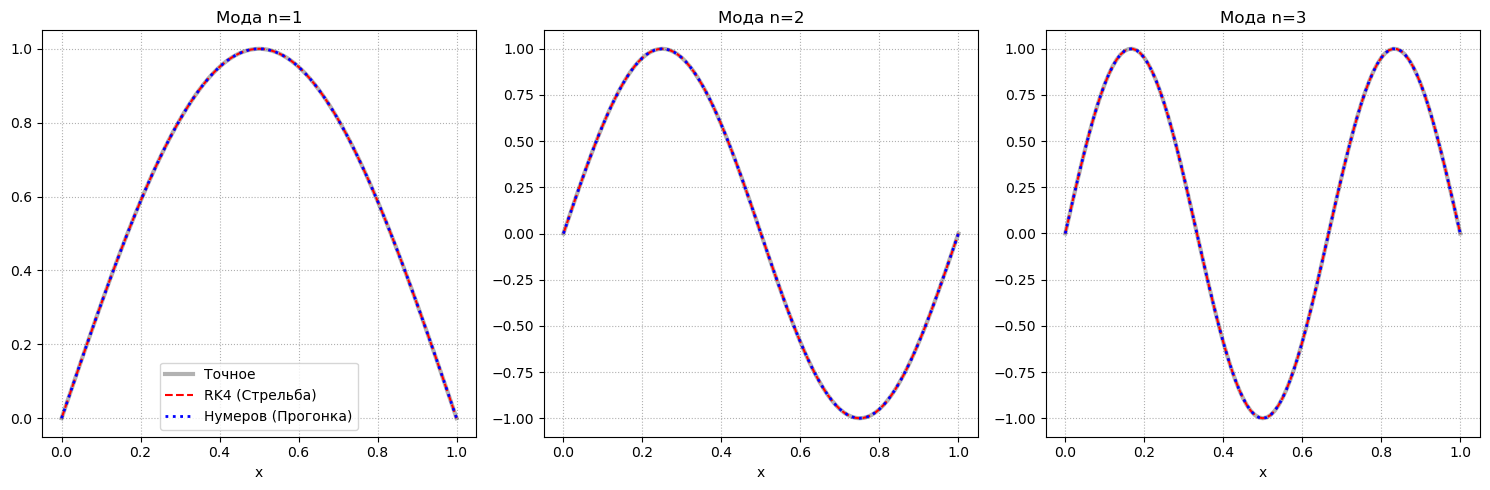

In [39]:
# ==========================================
# 3. РАСЧЕТ И СРАВНЕНИЕ
# ==========================================

modes = [1, 2, 3]
print(f"{'n':^3} | {'Exact':^10} | {'Shoot':^10} | {'Numerov':^10} | {'Err Sh':^9} | {'Err Num':^9}")
print("-" * 75)

plt.figure(figsize=(15, 5))

for i, n in enumerate(modes):
    k_ex = exact_k(n)
    
    # ----------------- Стрельба -----------------
    k_sh = brentq(shoot_residual, k_ex - 0.5, k_ex + 0.5)
    y_sh = solve_ode(k_sh)
    y_sh /= np.max(np.abs(y_sh))
    
    # ----------------- Нумеров -----------------
    k_num, y_num = numerov_inverse_iteration(n)
    if np.sign(y_num[1]) != np.sign(exact_y(n, x)[1]): 
        y_num *= -1

    print(f"{n:3d} | {k_ex:10.5f} | {k_sh:10.5f} | {k_num:10.5f} | {abs(k_ex-k_sh):.2e} | {abs(k_ex-k_num):.2e}")

    # ----------------- Отрисовка -----------------
    plt.subplot(1, 3, i + 1)
    plt.plot(x, exact_y(n, x), 'k-', lw=3, alpha=0.3, label='Точное')
    plt.plot(x, y_sh, 'r--', lw=1.5, label='RK4 (Стрельба)')
    plt.plot(x, y_num, 'b:', lw=2, label='Нумеров (Прогонка)')
    plt.title(f'Мода n={n}')
    plt.xlabel('x')
    plt.grid(True, linestyle=':')
    if i == 0: 
        plt.legend()

plt.tight_layout()
plt.show()

# Задание 2. Уравнение гиперболического типа

## Теоретическая справка: Численное решение нелинейного уравнения переноса (уравнение Бюргерса)

Уравнение вида $u_t + A(u)u_x = 0$ является гиперболическим, если матрица $A$ (или скаляр в данном случае) имеет только действительные собственные значения. Скорость переноса (собственное значение) здесь равна $\lambda = u$. Так как $\lambda$ — вещественное число, существуют действительные характеристические кривые ($dx/dt = u$). Следовательно, тип уравнения — строго гиперболический.

### 1. Физический смысл моделируемого процесса

Представьте поток машин на узкой трассе или волну на воде. Если автомобили сзади едут быстрее, чем автомобили спереди, они начинают догонять друг друга, образуя плотную пробку (ударную волну или разрыв).

Математически этот процесс описывается уравнением переноса. В рассматриваемом случае скорость перемещения волны $u$ зависит от самой волны $u$. То есть высокие участки волны движутся быстрее, чем низкие. Это классическое нелинейное уравнение, часто называемое уравнением Бюргерса (без вязкости).

В задаче представлены две формы записи этого уравнения.

**Недивергентная (квазилинейная) форма:**

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = 0$$

Здесь напрямую сказано: изменение величины со временем ($u_t$) плюс перенос этой величины со скоростью $u$ ($u \cdot u_x$) в сумме дают ноль.

**Дивергентная (консервативная) форма:**

$$\frac{\partial u}{\partial t} + \frac{\partial (u^2/2)}{\partial x} = 0$$

Математически (по правилу дифференцирования сложной функции) это то же самое уравнение. Но физически оно записано через поток $F(u) = u^2/2$. Эта форма означает строгий закон сохранения: сколько «вещества» втекло в объём, столько из него и вытекло.

**Зачем нужны две формы?** Для плавных волн (без резких скачков) обе формы дают одинаковый результат. Но как только волна опрокидывается и возникает резкий скачок (ударная волна), недивергентная форма ломается. Она начинает неправильно вычислять скорость движения этого скачка. Дивергентная форма, благодаря закону сохранения, корректно обрабатывает разрыв и считает скорость волны верно. Одно из главных заданий исследователя в этой задаче — увидеть эту разницу на графиках.

### 2. Начальные профили: прямоугольник и треугольник

В задаче даны два начальных состояния (форма волны в момент времени $t = 0$).

**Прямоугольник (ступенька).** Это уже готовый разрыв. Левый край (где значения возрастают) будет двигаться вперёд как ударная волна. Правый край (где значения падают) начнёт расплываться — это называется волной разрежения, так как быстрые частицы убегают от медленных.

**Треугольник.** Сначала это плавная горка. Но поскольку вершина горки движется быстрее её основания, передний склон начинает становиться всё круче, пока треугольник не опрокинется и не превратится в резкую ступеньку (ударную волну).

### 3. Численные методы (разностные схемы)

Чтобы найти решение, разбиваем пространство и время на сетку — набор точек с шагом $h$ (по координате) и шагом $\tau$ (по времени). Производные заменяются на разности между соседними узлами сетки, поэтому методы называются разностными схемами.

В задаче требуется сравнить четыре метода.

#### 3.1. Схемы первого порядка точности

Эти методы грубее и вносят в решение так называемую схемную вязкость. Они работают как фильтр, размывая резкие границы.

**Схема Лакса (Lax).** Самый простой метод. Вместо значения в текущей точке он берёт среднее арифметическое соседних узлов. Из-за этого схема сильно сглаживает (размывает) резкие скачки. Ступенька быстро превращается в пологий холм.

*Недивергентная форма:*

$$u_i^{n+1} = \frac{1}{2}(u_{i+1}^n + u_{i-1}^n) - \frac{\tau}{2h} u_i^n (u_{i+1}^n - u_{i-1}^n)$$

*Дивергентная форма (с потоком $F = u^2/2$):*

$$u_i^{n+1} = \frac{1}{2}(u_{i+1}^n + u_{i-1}^n) - \frac{\tau}{2h} (F_{i+1}^n - F_{i-1}^n)$$

**Схема Куранта–Изаксона–Риса (CIR, метод против потока).** Более умный метод. Он определяет направление потока и берёт разность именно с той стороны, откуда дует ветер. Схема тоже размывает профиль, но значительно слабее и аккуратнее, чем схема Лакса.

*Недивергентная форма (для положительной скорости $u > 0$):*

$$u_i^{n+1} = u_i^n - u_i^n \frac{\tau}{h} (u_i^n - u_{i-1}^n)$$

В общем виде (с учётом знака скорости) схема записывается как:

$$u_i^{n+1} = u_i^n - \frac{\tau}{h} \left( u_i^n \frac{u_i^n - u_{i-1}^n}{2} (1 + \operatorname{sgn} u_i^n) + u_i^n \frac{u_{i+1}^n - u_i^n}{2} (1 - \operatorname{sgn} u_i^n) \right)$$

*Дивергентная форма:*

$$u_i^{n+1} = u_i^n - \frac{\tau}{h} (F_i^n - F_{i-1}^n), \quad \text{где} \quad F_i = \frac{u_i^2}{2}$$

#### 3.2. Схемы второго порядка точности

Эти методы строятся на разложениях в ряды Тейлора более высокого порядка. Они лучше сохраняют крутизну волны, но имеют серьёзный недостаток: вблизи резких скачков они генерируют нефизичные осцилляции («рябь»). Это фундаментальное ограничение, известное как теорема Годунова.

**Схема Лакса–Вендроффа (Lax–Wendroff).** Классическая схема второго порядка. Она хорошо сохраняет форму прямоугольника, но перед самим обрывом и сразу после него возникает синусоидальная «гребёнка» (пульсации).

*Недивергентная форма:*

$$u_i^{n+1} = u_i^n - u_i^n \frac{\tau}{2h} (u_{i+1}^n - u_{i-1}^n) + (u_i^n)^2 \frac{\tau^2}{2h^2} (u_{i+1}^n - 2u_i^n + u_{i-1}^n)$$

*Дивергентная форма (более сложная, требует вычисления производной потока $A(u) = dF/du = u$ в полуцелых точках):*

$$\begin{aligned}
u_i^{n+1} = u_i^n &- \frac{\tau}{2h} (F_{i+1}^n - F_{i-1}^n) \\
&+ \frac{\tau^2}{2h^2} \left[ A_{i+1/2}^n (F_{i+1}^n - F_i^n) - A_{i-1/2}^n (F_i^n - F_{i-1}^n) \right],
\end{aligned}$$

где $A_{i+1/2}^n = \frac{1}{2}(u_{i+1}^n + u_i^n)$.

**Схема МакКормака (MacCormack).** Популярный в аэродинамике метод типа «предиктор–корректор». Расчёт выполняется в два шага: сначала грубо предсказывается (predictor) будущее состояние, затем оно уточняется (corrector). Результаты схожи со схемой Лакса–Вендроффа (высокая точность плюс осцилляции на разрывах), но схема МакКормака часто оказывается более устойчивой.

*Недивергентная форма:*

**Предиктор (шаг вперёд, правая разность):**

$$u_i^* = u_i^n - u_i^n \frac{\tau}{h} (u_{i+1}^n - u_i^n)$$

**Корректор (шаг назад, левая разность):**

$$u_i^{n+1} = \frac{1}{2} \left[ u_i^n + u_i^* - u_i^* \frac{\tau}{h} (u_i^* - u_{i-1}^*) \right]$$

*Дивергентная форма:*

**Предиктор:**

$$u_i^* = u_i^n - \frac{\tau}{h} (F_{i+1}^n - F_i^n)$$

**Корректор (с использованием потока, вычисленного по предсказанному полю $F^*$):**

$$u_i^{n+1} = \frac{1}{2} \left[ u_i^n + u_i^* - \frac{\tau}{h} (F_i^* - F_{i-1}^*) \right]$$

### 4. Условие устойчивости (число Куранта)

Для всех явных схем существует ограничение на шаг по времени, связанное с максимальной скоростью распространения возмущений:

$$\text{CFL} = \frac{\max(|u|) \cdot \tau}{h} \le 1$$

Это условие Куранта–Фридрихса–Леви (Courant–Friedrichs–Lewy). Физически оно означает, что за один шаг по времени волна не должна проходить расстояние, большее чем шаг сетки. При нарушении этого условия численное решение становится неустойчивым и быстро «взрывается» (появляются растущие осцилляции).

### 5. Исследование сходимости при $h \to 0$

**Для схем первого порядка (Лакс, CIR).** Уменьшение шага сетки приводит к тому, что размытый «размазанный» фронт становится уже. Чем мельче сетка, тем ближе график к идеальной ступеньке. Скорость сходимости — первый порядок: ошибка уменьшается пропорционально $h$.

**Для схем второго порядка (Лакс–Вендрофф, МакКормак).** Уменьшение шага сетки не убирает рябь. Пульсации становятся более частыми (высокочастотными) и прижимаются ближе к самому разрыву, но их амплитуда остаётся примерно такой же (эффект Гиббса). Это яркая демонстрация того, как классические схемы высоких порядков ведут себя на разрывных решениях. Скорость сходимости на гладких участках — второй порядок, но вблизи разрыва порядок падает до первого.

In [40]:
# ==========================================
# 1. НАСТРОЙКА ПАРАМЕТРОВ И СЕТКИ
# ==========================================

L: float = 10.0           # Длина пространственной области
T: float = 2.0            # Конечное время моделирования
nx: int = 200             # Количество узлов по пространству
h: float = L / nx         # Шаг по пространству

# Shape: (nx,)
x: np.ndarray = np.linspace(0, L, nx)

u_max: float = 1.0        
cfl: float = 0.5          # Число Куранта
tau: float = cfl * h / u_max # Шаг по времени
nt: int = int(T / tau)    # Количество шагов по времени

In [41]:
# ==========================================
# 2. НАЧАЛЬНЫЕ УСЛОВИЯ
# ==========================================

def init_square() -> np.ndarray:
    """
    Формирует начальный профиль в виде прямоугольного импульса (ступеньки).

    Returns
    -------
    - u : (nx,) ndarray
        Массив значений начального профиля.

    Notes
    -----
    • *Algorithm workflow*
    1. Инициализация нулевого массива размера nx.
    2. Установка значений 1.0 в интервале 2 <= x <= 4.
    """
    # Shape: (nx,)
    u = np.zeros(nx)
    u[(x >= 2) & (x <= 4)] = 1.0
    return u

def init_triangle() -> np.ndarray:
    """
    Формирует начальный профиль в виде треугольного импульса.

    Returns
    -------
    - u : (nx,) ndarray
        Массив значений начального профиля.

    Notes
    -----
    • *Algorithm workflow*
    1. Инициализация нулевого массива размера nx.
    2. Построение треугольника с вершиной в точке x=3 (значение 1.0) 
       на интервале 2 <= x <= 4.
    """
    # Shape: (nx,)
    u = np.zeros(nx)
    # Shape: (nx,) boolean array
    mask = (x >= 2) & (x <= 4)
    u[mask] = 1.0 - np.abs(x[mask] - 3.0)
    return u

In [42]:
# ==========================================
# 3. ЧИСЛЕННЫЕ СХЕМЫ
# ==========================================

def flux(u: np.ndarray) -> np.ndarray:
    """
    Вычисляет функцию потока F(u) для уравнения Бюргерса в дивергентной форме.

    Parameters
    ----------
    - u : (nx,) ndarray
        Профиль величины.

    Returns
    -------
    - F : (nx,) ndarray
        Вычисленные значения потока.

    Notes
    -----
    • *Mathematical foundation*
    - Функция потока: F(u) = u^2 / 2.
    """
    # Shape: (nx,)
    return 0.5 * u**2

# --- Схема Лакса ---

def lax_step_non_div(u: np.ndarray, h: float, tau: float) -> np.ndarray:
    """
    Выполняет один временной шаг по схеме Лакса (недивергентная форма).

    Parameters
    ----------
    - u : (nx,) ndarray
        Профиль скорости на текущем слое n.
    - h : float
        Шаг пространственной сетки.
    - tau : float
        Шаг по времени.

    Returns
    -------
    - un : (nx,) ndarray
        Профиль скорости на следующем слое n+1.

    Notes
    -----
    • *Mathematical foundation*
    - Уравнение: u_t + u u_x = 0
    - Аппроксимация: u_i^{(n+1)} = 0.5 (u_{i+1}^n + u_{i-1}^n) - (tau / 2h) u_i^n (u_{i+1}^n - u_{i-1}^n).
    """
    un = u.copy()
    
    # ----------------------------------
    #     1. Расчет внутренних узлов
    # ----------------------------------
    # Shape: (nx-2,)
    un[1:-1] = 0.5 * (u[2:] + u[:-2]) - u[1:-1] * (tau / (2 * h)) * (u[2:] - u[:-2])
    
    # ----------------------------------
    #     2. Граничные условия
    # ----------------------------------
    un[0] = un[-1] = 0
    return un

def lax_step_div(u: np.ndarray, h: float, tau: float) -> np.ndarray:
    """
    Выполняет один временной шаг по схеме Лакса (дивергентная форма).

    Parameters
    ----------
    - u : (nx,) ndarray
        Профиль скорости на текущем слое n.
    - h : float
        Шаг пространственной сетки.
    - tau : float
        Шаг по времени.

    Returns
    -------
    - un : (nx,) ndarray
        Профиль скорости на следующем слое n+1.

    Notes
    -----
    • *Mathematical foundation*
    - Уравнение: u_t + F(u)_x = 0
    - Аппроксимация: u_i^{(n+1)} = 0.5 (u_{i+1}^n + u_{i-1}^n) - (tau / 2h) (F_{i+1}^n - F_{i-1}^n).
    """
    un = u.copy()
    # Shape: (nx,)
    F = flux(u)
    
    # ----------------------------------
    #     1. Расчет внутренних узлов
    # ----------------------------------
    # Shape: (nx-2,)
    un[1:-1] = 0.5 * (u[2:] + u[:-2]) - (tau / (2 * h)) * (F[2:] - F[:-2])
    
    un[0] = un[-1] = 0
    return un

# --- Схема Куранта-Изаксона-Риса ---

def cir_step_non_div(u: np.ndarray, h: float, tau: float) -> np.ndarray:
    """
    Выполняет один шаг по схеме Куранта-Изаксона-Риса (CIR) для недивергентной формы.

    Parameters
    ----------
    - u : (nx,) ndarray
        Профиль скорости на текущем слое n.
    - h : float
        Шаг пространственной сетки.
    - tau : float
        Шаг по времени.

    Returns
    -------
    - un : (nx,) ndarray
        Профиль скорости на следующем слое n+1.

    Notes
    -----
    • *Mathematical foundation*
    - Метод против потока (Upwind scheme). Для u > 0 берется левая разность.
    - Аппроксимация: u_i^{(n+1)} = u_i^n - u_i^n (tau / h) (u_i^n - u_{i-1}^n).
    """
    un = u.copy()
    
    # ----------------------------------
    #     1. Перенос слева направо
    # ----------------------------------
    # Shape: (nx-1,)
    un[1:] = u[1:] - u[1:] * (tau / h) * (u[1:] - u[:-1])
    
    un[0] = 0
    return un

def cir_step_div(u: np.ndarray, h: float, tau: float) -> np.ndarray:
    """
    Выполняет один шаг по схеме CIR для дивергентной формы.

    Parameters
    ----------
    - u : (nx,) ndarray
        Профиль скорости на текущем слое n.
    - h : float
        Шаг пространственной сетки.
    - tau : float
        Шаг по времени.

    Returns
    -------
    - un : (nx,) ndarray
        Профиль скорости на следующем слое n+1.

    Notes
    -----
    • *Mathematical foundation*
    - Аппроксимация с потоком: u_i^{(n+1)} = u_i^n - (tau / h) (F_i^n - F_{i-1}^n).
    """
    un = u.copy()
    # Shape: (nx,)
    F = flux(u)
    
    # ----------------------------------
    #     1. Перенос слева направо
    # ----------------------------------
    # Shape: (nx-1,)
    un[1:] = u[1:] - (tau / h) * (F[1:] - F[:-1])
    
    un[0] = 0
    return un

# --- Схема Лакса-Вендроффа ---

def lw_step_non_div(u: np.ndarray, h: float, tau: float) -> np.ndarray:
    """
    Выполняет один шаг по схеме Лакса-Вендроффа (недивергентная форма).

    Parameters
    ----------
    - u : (nx,) ndarray
        Профиль скорости на текущем слое n.
    - h : float
        Шаг пространственной сетки.
    - tau : float
        Шаг по времени.

    Returns
    -------
    - un : (nx,) ndarray
        Профиль скорости на следующем слое n+1.

    Notes
    -----
    • *Mathematical foundation*
    - Схема 2-го порядка точности.
    - u_i^{(n+1)} = u_i^n - u_i^n (tau / 2h) (u_{i+1}^n - u_{i-1}^n) + (u_i^n)^2 (tau^2 / 2h^2) (u_{i+1}^n - 2u_i^n + u_{i-1}^n).
    """
    un = u.copy()
    
    # ----------------------------------
    #     1. Расчет внутренних узлов
    # ----------------------------------
    # Shape: (nx-2,)
    un[1:-1] = u[1:-1] - u[1:-1] * (tau / (2 * h)) * (u[2:] - u[:-2]) + \
               (u[1:-1]**2) * (tau**2 / (2 * h**2)) * (u[2:] - 2*u[1:-1] + u[:-2])
               
    un[0] = un[-1] = 0
    return un

def lw_step_div(u: np.ndarray, h: float, tau: float) -> np.ndarray:
    """
    Выполняет один шаг по схеме Лакса-Вендроффа (дивергентная форма).

    Parameters
    ----------
    - u : (nx,) ndarray
        Профиль скорости на текущем слое n.
    - h : float
        Шаг пространственной сетки.
    - tau : float
        Шаг по времени.

    Returns
    -------
    - un : (nx,) ndarray
        Профиль скорости на следующем слое n+1.

    Notes
    -----
    • *Mathematical foundation*
    - Требует вычисления производной потока A(u) = dF/du = u в полуцелых точках.
    - u_i^{(n+1)} = u_i^n - (tau / 2h) (F_{i+1} - F_{i-1}) + (tau^2 / 2h^2) [A_{i+1/2}(F_{i+1} - F_i) - A_{i-1/2}(F_i - F_{i-1})].
    """
    un = u.copy()
    # Shape: (nx,)
    F = flux(u)
    
    # ----------------------------------
    #     1. Значения A в полуцелых точках
    # ----------------------------------
    # Shape: (nx-2,)
    A_plus = 0.5 * (u[2:] + u[1:-1])
    A_minus = 0.5 * (u[1:-1] + u[:-2])
    
    # ----------------------------------
    #     2. Обновление значений
    # ----------------------------------
    # Shape: (nx-2,)
    un[1:-1] = u[1:-1] - (tau / (2 * h)) * (F[2:] - F[:-2]) + \
               (tau**2 / (2 * h**2)) * (A_plus * (F[2:] - F[1:-1]) - A_minus * (F[1:-1] - F[:-2]))
               
    un[0] = un[-1] = 0
    return un

# --- Схема МакКормака (Предиктор-Корректор типа Уорминга) ---

def maccormack_step_non_div(u: np.ndarray, h: float, tau: float) -> np.ndarray:
    """
    Выполняет один шаг по схеме МакКормака (недивергентная форма).

    Parameters
    ----------
    - u : (nx,) ndarray
        Профиль скорости на текущем слое n.
    - h : float
        Шаг пространственной сетки.
    - tau : float
        Шаг по времени.

    Returns
    -------
    - un : (nx,) ndarray
        Профиль скорости на следующем слое n+1.

    Notes
    -----
    • *Mathematical foundation*
    - Предиктор (шаг вперед): u_i^* = u_i^n - u_i^n (tau / h) (u_{i+1}^n - u_i^n).
    - Корректор (шаг назад): u_i^{(n+1)} = 0.5 [u_i^n + u_i^* - u_i^* (tau / h) (u_i^* - u_{i-1}^*)].
    """
    un = u.copy()
    u_star = u.copy()
    
    # ----------------------------------
    #     1. Предиктор (вперед)
    # ----------------------------------
    # Shape: (nx-1,)
    u_star[0:-1] = u[0:-1] - u[0:-1] * (tau / h) * (u[1:] - u[0:-1])
    u_star[-1] = 0
    
    # ----------------------------------
    #     2. Корректор (назад)
    # ----------------------------------
    # Shape: (nx-1,)
    un[1:] = 0.5 * (u[1:] + u_star[1:] - u_star[1:] * (tau / h) * (u_star[1:] - u_star[:-1]))
    un[0] = 0
    return un

def maccormack_step_div(u: np.ndarray, h: float, tau: float) -> np.ndarray:
    """
    Выполняет один шаг по схеме МакКормака (дивергентная форма).

    Parameters
    ----------
    - u : (nx,) ndarray
        Профиль скорости на текущем слое n.
    - h : float
        Шаг пространственной сетки.
    - tau : float
        Шаг по времени.

    Returns
    -------
    - un : (nx,) ndarray
        Профиль скорости на следующем слое n+1.

    Notes
    -----
    • *Mathematical foundation*
    - Предиктор: u_i^* = u_i^n - (tau / h) (F_{i+1}^n - F_i^n).
    - Корректор: u_i^{(n+1)} = 0.5 [u_i^n + u_i^* - (tau / h) (F_i^* - F_{i-1}^*)].
    """
    un = u.copy()
    u_star = u.copy()
    # Shape: (nx,)
    F = flux(u)
    
    # ----------------------------------
    #     1. Предиктор (вперед)
    # ----------------------------------
    # Shape: (nx-1,)
    u_star[0:-1] = u[0:-1] - (tau / h) * (F[1:] - F[0:-1])
    u_star[-1] = 0
    
    # Вычисление потока по промежуточному полю
    # Shape: (nx,)
    F_star = flux(u_star)
    
    # ----------------------------------
    #     2. Корректор (назад)
    # ----------------------------------
    # Shape: (nx-1,)
    un[1:] = 0.5 * (u[1:] + u_star[1:] - (tau / h) * (F_star[1:] - F_star[:-1]))
    un[0] = 0
    return un

In [43]:
# ==========================================
# 4. ЗАПУСК РАСЧЕТОВ
# ==========================================

# Словарь с парами функций (недивергентная, дивергентная) для каждого метода
schemes: Dict[str, Tuple[Callable, Callable]] = {
    'Лакса': (lax_step_non_div, lax_step_div),
    'CIR (Левый угол)': (cir_step_non_div, cir_step_div),
    'Лакса-Вендроффа': (lw_step_non_div, lw_step_div),
    'МакКормака (WKL)': (maccormack_step_non_div, maccormack_step_div)
}

def solve_and_plot(init_func: Callable[[], np.ndarray], title: str) -> None:
    """
    Запускает расчеты для всех схем и строит графики сравнения.

    Parameters
    ----------
    - init_func : Callable[[], np.ndarray]
        Функция генерации начального профиля (init_square или init_triangle).
    - title : str
        Заголовок для графиков.

    Returns
    -------
    - None

    Notes
    -----
    • *Algorithm workflow*
    1. Инициализация фигуры matplotlib с двумя подграфиками (для двух форм уравнения).
    2. Цикл по недивергентной и дивергентной формам.
    3. Внутренний цикл по каждой численной схеме с итерациями по времени `nt`.
    4. Отрисовка полученного решения `u` для каждого метода.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=16)

    for i, mode in enumerate(['Недивергентная форма', 'Дивергентная форма']):
        ax = axes[i]
        
        # Отрисовка начального профиля
        ax.plot(x, init_func(), 'k--', label='t=0 (Начальный профиль)')
        
        for name, funcs in schemes.items():
            # Shape: (nx,)
            u = init_func()
            step_func = funcs[i] # Индекс 0 - недиверг., 1 - диверг.
            
            # ----------------------------------
            #     Интегрирование по времени
            # ----------------------------------
            for _ in range(nt):
                # Обновление профиля на каждом шаге
                u = step_func(u, h, tau)
            
            ax.plot(x, u, label=name)
        
        ax.set_title(mode)
        ax.set_xlabel('x')
        ax.set_ylabel('u')
        ax.set_ylim(-0.2, 1.2)
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()

Шаг по x: h = 0.0500
Шаг по t: tau = 0.0250


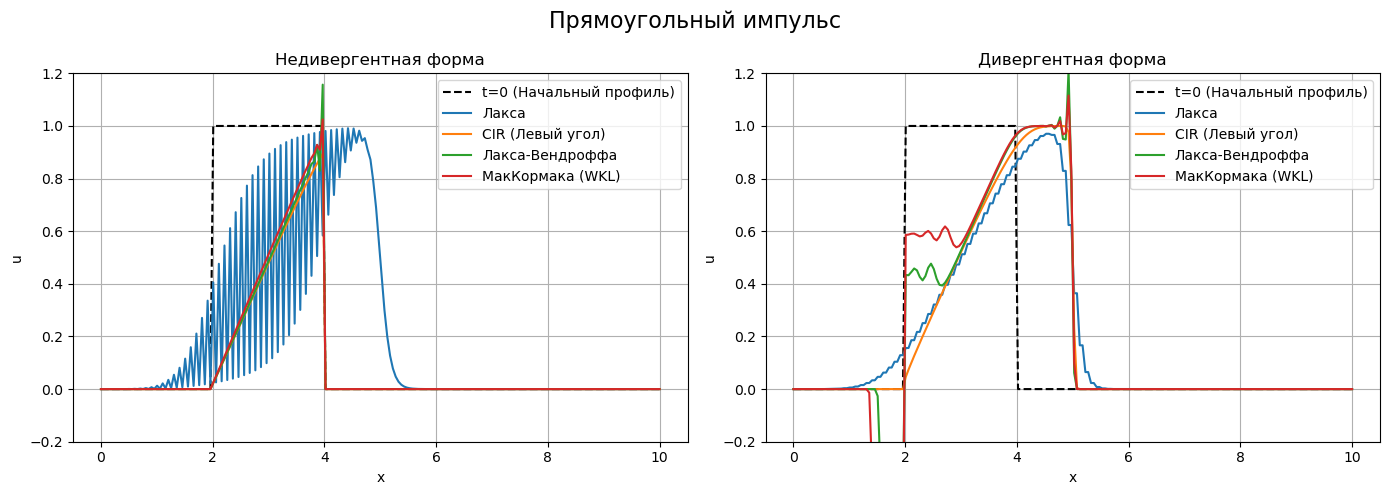

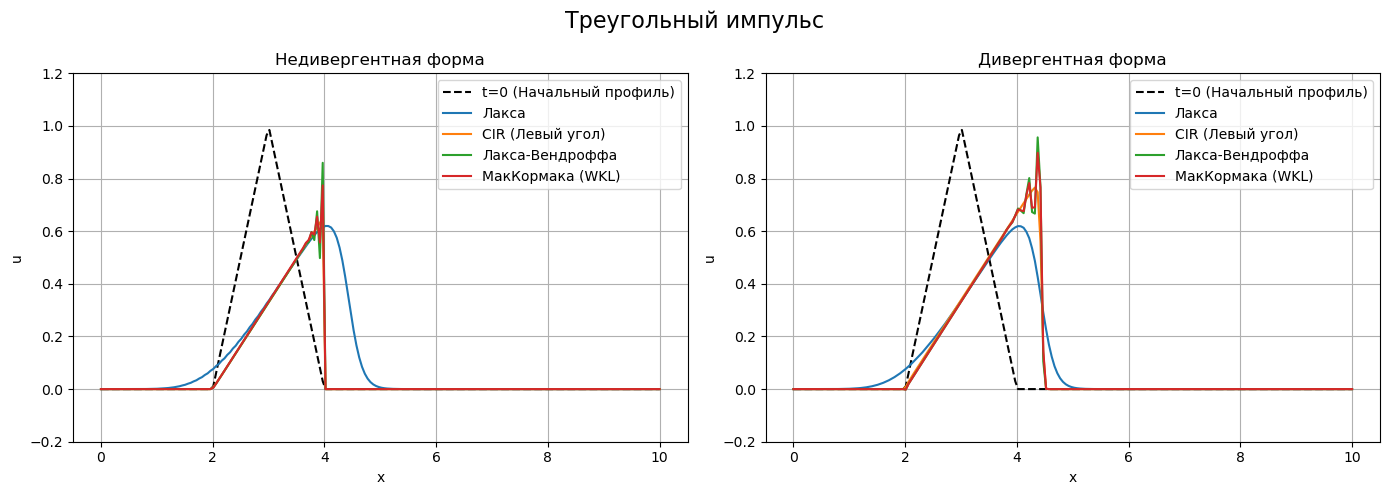

In [44]:
# ----------------------------------
#        Вывод параметров
# ----------------------------------
print(f"Шаг по x: h = {h:.4f}")
print(f"Шаг по t: tau = {tau:.4f}")

# Запуск для прямоугольного профиля
solve_and_plot(init_square, 'Прямоугольный импульс')

# Запуск для треугольного профиля
solve_and_plot(init_triangle, 'Треугольный импульс')

# Задание 3. Уравнение параболического типа


## Теоретическая справка: Моделирование промерзания водоёма (задача Стефана)

### 1. Физический смысл моделируемого процесса

Представьте озеро зимой. На дне озера температура положительная (вода), а на поверхности — сильный мороз (воздух ниже нуля). На поверхности начинает образовываться лёд. Со временем слой льда утолщается, и граница между льдом и водой (фронт замерзания) медленно опускается вниз.

Главная физическая сложность здесь — фазовый переход. Когда вода превращается в лёд, она выделяет большое количество скрытой энергии — удельную теплоту плавления. Чтобы лёд продолжал расти, эту выделившуюся энергию нужно отвести наверх, к холодному воздуху, через уже замёрзший слой льда. Поэтому скорость роста льда зависит от баланса тепла: сколько тепла отводится наверх через лёд и сколько тепла поступает снизу от тёплой воды.

### 2. Математический тип задачи

В математической физике эта задача имеет следующую классификацию.

Базовый тип уравнений — это уравнения в частных производных параболического типа. Параболические уравнения описывают процессы выравнивания, диффузии и теплопроводности, то есть распространения тепла с течением времени.

Специфический класс задачи — это задача со свободной (подвижной) границей, исторически известная как задача Стефана. Обычно при решении уравнений мы заранее знаем границы объекта, например длину стержня. В задаче Стефана граница раздела сред (вода – лёд) постоянно движется, и мы не знаем заранее, где она окажется в следующий момент времени. Нахождение положения этой границы является частью самой задачи.

Математически это описывается так называемым условием Стефана на границе льда и воды:

$$\rho L \frac{dy}{dt} = \lambda_{\text{лёд}} \frac{\partial T_{\text{лёд}}}{\partial x} - \lambda_{\text{вода}} \frac{\partial T_{\text{вода}}}{\partial x}.$$

Скорость движения границы $dy/dt$ прямо пропорциональна разности тепловых потоков изо льда и из воды.

### 3. Метод сглаживания (метод эффективной теплоёмкости)

Решать задачу с движущейся границей «в лоб» очень сложно, потому что компьютерная сетка (набор точек, в которых мы считаем температуру) фиксирована, а фронт льда скользит между этими точками.

Чтобы обойти это, в вычислительной теплофизике применяют метод сглаживания (также называемый методом эффективной теплоёмкости или методом энтальпии). Суть метода заключается в следующем. Вместо того чтобы считать лёд и воду двумя разными объектами с чёткой границей, мы представляем водоём как единую среду. Мы «обманываем» математику, предполагая, что вода замерзает не ровно при 0 °C (273 К), а в очень узком интервале, например от –0,5 °C до +0,5 °C.

В этом маленьком интервале мы искусственно задаём среде гигантскую теплоёмкость. Компьютер «видит», что при прохождении через 0 °C среде нужно отдать колоссальное количество энергии, чтобы остыть дальше. Это идеально имитирует выделение скрытой теплоты кристаллизации. В результате нам больше не нужно отслеживать саму границу: уравнение теплопроводности становится единым для всего водоёма.

### 4. Разностные схемы для уравнения теплопроводности

После применения метода сглаживания мы получаем одно уравнение теплопроводности. Чтобы решить его, время и пространство разбиваются на дискретные шаги (узлы сетки). В задаче используются три классические разностные схемы расчёта будущей температуры по прошлым значениям. Они отличаются тем, какие точки (шаблоны) берутся для расчёта.

#### 4.1. Явная схема (схема Эйлера)

Явная схема рассчитывает будущую температуру в точке только на основе уже известных текущих температур самой точки и её соседей. Формула расчёта имеет следующий вид:

$$T_i^{n+1} = T_i^n + \frac{\Delta t}{C_i^n \Delta x^2} \left[ \lambda_{i+1/2}^n (T_{i+1}^n - T_i^n) - \lambda_{i-1/2}^n (T_i^n - T_{i-1}^n) \right].$$

Для случая постоянных теплофизических свойств ($\lambda$, $C$ = const) формула упрощается:

$$T_i^{n+1} = T_i^n + \frac{\lambda \Delta t}{C \Delta x^2} (T_{i-1}^n - 2T_i^n + T_{i+1}^n).$$

Плюс явной схемы — простота расчётной формулы. Минус — она условно устойчива. Если сделать шаг по времени чуть больше дозволенного математикой, вычисления «взорвутся»: на графиках появятся дикие, растущие до бесконечности зигзаги. Условие устойчивости (число Куранта для теплопроводности) записывается как

$$\frac{\lambda \Delta t}{C \Delta x^2} \le \frac{1}{2}.$$

#### 4.2. Неявная схема

Неявная схема рассчитывает будущую температуру в точке с использованием будущих же температур соседних точек. Получается система уравнений, где всё зависит от всего, и её нужно решать матричными методами, например методом прогонки. Дискретный аналог записывается так:

$$C_i^{n+1} \frac{T_i^{n+1} - T_i^n}{\Delta t} = \frac{1}{\Delta x^2} \left[ \lambda_{i+1/2}^{n+1} (T_{i+1}^{n+1} - T_i^{n+1}) - \lambda_{i-1/2}^{n+1} (T_i^{n+1} - T_{i-1}^{n+1}) \right].$$

Для постоянных $\lambda$ и $C$ после приведения подобных получаем:

$$-r T_{i-1}^{n+1} + (1 + 2r) T_i^{n+1} - r T_{i+1}^{n+1} = T_i^n, \quad \text{где} \quad r = \frac{\lambda \Delta t}{C \Delta x^2}.$$

Это система линейных уравнений с трёхдиагональной матрицей, которая решается методом прогонки за $O(N)$ операций. Плюс неявной схемы — она абсолютно устойчива. Можно делать любые большие шаги по времени, решение никогда не «взорвётся» математически (хотя физически станет грубее).

#### 4.3. Схема Кранка – Николсона

Схема Кранка – Николсона представляет собой «золотую середину». Она берёт среднее арифметическое между явной и неявной схемами. Формула расчёта выглядит следующим образом:

$$C_i^{n+1/2} \frac{T_i^{n+1} - T_i^n}{\Delta t} = \frac{1}{2\Delta x^2} \Bigg[ \lambda_{i+1/2}^{n} (T_{i+1}^{n} - T_i^{n}) - \lambda_{i-1/2}^{n} (T_i^{n} - T_{i-1}^{n}) + \lambda_{i+1/2}^{n+1} (T_{i+1}^{n+1} - T_i^{n+1}) - \lambda_{i-1/2}^{n+1} (T_i^{n+1} - T_{i-1}^{n+1}) \Bigg].$$

Для постоянных $\lambda$ и $C$ классический компактный вид схемы таков:

$$T_i^{n+1} = T_i^n + \frac{r}{2} \left[ (T_{i-1}^n - 2T_i^n + T_{i+1}^n) + (T_{i-1}^{n+1} - 2T_i^{n+1} + T_{i+1}^{n+1}) \right], \quad r = \frac{\lambda \Delta t}{C \Delta x^2}.$$

В форме, удобной для решения СЛАУ, схема записывается как

$$-\frac{r}{2} T_{i-1}^{n+1} + (1 + r) T_i^{n+1} - \frac{r}{2} T_{i+1}^{n+1} = \frac{r}{2} T_{i-1}^n + (1 - r) T_i^n + \frac{r}{2} T_{i+1}^n.$$

Плюсы схемы Кранка – Николсона: она сочетает абсолютную устойчивость (как неявная схема) и обладает более высокой (второй) точностью по времени. В инженерной практике для расчёта теплопроводности чаще всего используют именно её.


In [45]:
# ==========================================
# 1. ФИЗИЧЕСКИЕ И ГЕОМЕТРИЧЕСКИЕ ПАРАМЕТРЫ
# ==========================================
L_len: float = 1.0         # Глубина водоема, м
Tp: float = 273.0          # Температура плавления, К
rho: float = 1000.0        # Плотность, кг/м^3 (считаем неизменной)
cs: float = 2100.0         # Теплоемкость льда, Дж/(кг*К)
cf: float = 4200.0         # Теплоемкость воды, Дж/(кг*К)
lams: float = 2.25         # Теплопроводность льда, Вт/(м*К) (a_s в тексте)
lamf: float = 0.56         # Теплопроводность воды, Вт/(м*К) (a_f в тексте)
L_heat: float = 3.3e5      # Удельная теплота плавления, Дж/кг

deltaT: float = 0.5        # Полуширина интервала сглаживания фазового перехода, К

In [46]:
# ==========================================
# 2. ПАРАМЕТРЫ СЕТКИ И ВРЕМЕНИ
# ==========================================
Nx: int = 100
dx: float = L_len / Nx

# Shape: (Nx+1,)
x: np.ndarray = np.linspace(0, L_len, Nx + 1)

# Выбор разностной схемы (0.0 - Явная, 0.5 - Кранк-Николсон, 1.0 - Неявная)
theta: float = 0.5

# Шаг по времени. Для явной схемы есть жесткое ограничение устойчивости:
# dt <= dx^2 / (2 * a_max). Примем достаточно малый шаг.
dt: float = 20.0           # Шаг по времени, с
days: int = 10             # Моделируем 10 суток
t_max: float = days * 24 * 3600
Nt: int = int(t_max / dt)

In [47]:
# ==========================================
# 3. НАЧАЛЬНЫЕ И ГРАНИЧНЫЕ УСЛОВИЯ
# ==========================================

def g(x_val: np.ndarray) -> np.ndarray:
    """
    Задает начальный профиль температуры в водоеме.

    Parameters
    ----------
    - x_val : (Nx+1,) ndarray
        Массив пространственных координат.

    Returns
    -------
    - T_init : (Nx+1,) ndarray
        Профиль температуры в момент времени t=0.

    Notes
    -----
    • *Mathematical foundation*
    - Линейное распределение: T(x, 0) = 7.0 * (x / L) + 273.0
    """
    return 7.0 * x_val / L_len + 273.0

def f1(t_val: float) -> float:
    """
    Определяет граничное условие на поверхности водоема (x=0).

    Parameters
    ----------
    - t_val : float
        Текущее время в секундах.

    Returns
    -------
    - T_surface : float
        Температура на поверхности.

    Notes
    -----
    • *Mathematical foundation*
    - Температура падает по экспоненциальному закону: T(0, t) = 273.0 - 13.0 * (1 - exp(-10^{-5} t))
    """
    return 273.0 - 13.0 * (1.0 - np.exp(-1e-5 * t_val))

def f2(t_val: float) -> float:
    """
    Определяет граничное условие на дне водоема (x=L).

    Parameters
    ----------
    - t_val : float
        Текущее время в секундах.

    Returns
    -------
    - T_bottom : float
        Температура на дне.

    Notes
    -----
    • *Working hypotheses*
    - Температура на дне поддерживается постоянной (280 К).
    """
    return 280.0

def get_properties(T_arr: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Вычисляет теплофизические свойства среды в зависимости от температуры 
    с использованием метода эффективной теплоемкости (сглаживания).

    Parameters
    ----------
    - T_arr : (Nx+1,) ndarray
        Массив текущих температур в узлах сетки.

    Returns
    -------
    - C_eff : (Nx+1,) ndarray
        Массив эффективной объемной теплоемкости.
    - lam : (Nx+1,) ndarray
        Массив коэффициентов теплопроводности.

    Notes
    -----
    • *Mathematical foundation*
    - Лед (T < Tp - deltaT): C = rho * cs, lam = lams
    - Вода (T > Tp + deltaT): C = rho * cf, lam = lamf
    - Зона перехода: C = rho*(cs+cf)/2 + rho*L_heat/(2*deltaT), lam = (lams+lamf)/2

    • *Algorithm workflow*
    1. Инициализация массивов C_eff и lam нулями.
    2. Поэлементный проход по массиву T_arr.
    3. Присвоение свойств в зависимости от нахождения температуры относительно Tp.
    """
    # Shape: (Nx+1,)
    C_eff = np.zeros_like(T_arr)
    lam = np.zeros_like(T_arr)
    
    for i in range(len(T_arr)):
        if T_arr[i] < Tp - deltaT: # Твердая фаза (лед)
            C_eff[i] = rho * cs
            lam[i] = lams
        elif T_arr[i] > Tp + deltaT: # Жидкая фаза (вода)
            C_eff[i] = rho * cf
            lam[i] = lamf
        else:                        # Зона фазового перехода (размазанная)
            C_eff[i] = rho * (cs + cf) / 2.0 + rho * L_heat / (2.0 * deltaT)
            lam[i] = (lams + lamf) / 2.0
            
    return C_eff, lam

In [48]:
# ==========================================
# 4. ИНИЦИАЛИЗАЦИЯ
# ==========================================

# Shape: (Nx+1,)
T: np.ndarray = g(x)
T[0] = f1(0)
T[-1] = f2(0)

save_times: List[float] = [1*24*3600, 3*24*3600, 5*24*3600, 10*24*3600] # В секундах
saved_profiles: Dict[int, np.ndarray] = {}
front_time: List[float] = []
front_pos: List[float] =[]

In [49]:
# ==========================================
# 5. ГЛАВНЫЙ ЦИКЛ ИНТЕГРИРОВАНИЯ
# ==========================================

for n in range(1, Nt + 1):
    t = n * dt
    
    # ----------------------------------
    #     1. Свойства и коэффициенты
    # ----------------------------------
    
    # C_n, lam_n Shapes: (Nx+1,)
    C_n, lam_n = get_properties(T)
    
    # Коэффициенты теплопроводности на гранях ячеек (полуцелые индексы)
    # Используем среднее арифметическое между соседними узлами
    # Shape: (Nx,)
    lam_mid = 0.5 * (lam_n[:-1] + lam_n[1:])
    
    # ----------------------------------
    #     2. Сборка СЛАУ
    # ----------------------------------
    
    # Сборка трехдиагональной матрицы A и вектора правой части B (A * T_new = B)
    # Shapes: A_diag (Nx+1,), A_lower (Nx,), A_upper (Nx,), B (Nx+1,)
    A_diag = np.zeros(Nx + 1)
    A_lower = np.zeros(Nx)
    A_upper = np.zeros(Nx)
    B = np.zeros(Nx + 1)
    
    # Внутренние узлы
    for i in range(1, Nx):
        # Shape: scalar
        coef_L = lam_mid[i-1] * dt / (dx**2)
        coef_R = lam_mid[i] * dt / (dx**2)
        
        A_lower[i-1] = -theta * coef_L
        A_upper[i]   = -theta * coef_R
        A_diag[i]    = C_n[i] + theta * (coef_L + coef_R)
        
        B[i] = C_n[i] * T[i] + (1.0 - theta) * (coef_L * T[i-1] - (coef_L + coef_R) * T[i] + coef_R * T[i+1])
        
    # ----------------------------------
    #     3. Граничные условия и Решение
    # ----------------------------------
    
    A_diag[0] = 1.0; A_upper[0] = 0.0; B[0] = f1(t)
    A_diag[Nx] = 1.0; A_lower[Nx-1] = 0.0; B[Nx] = f2(t)
    
    # ВНИМАНИЕ: Ожидается импорт scipy.sparse как sp и scipy.sparse.linalg как spla
    A_sparse = sp.diags([A_lower, A_diag, A_upper], [-1, 0, 1], format='csc')
    
    # Shape: (Nx+1,)
    T_new = spla.spsolve(A_sparse, B)
    T = T_new
    
    # ----------------------------------
    #     4. Отслеживание фронта льда
    # ----------------------------------
    
    # Поиск положения фронта (где T пересекает Tp)
    # Shape: (M,) где M - количество узлов со льдом
    idx = np.where(T <= Tp)[0]
    
    if len(idx) > 0 and idx[-1] < Nx:
        i_f = idx[-1]
        if T[i_f+1] > Tp:
            # Линейная интерполяция между узлами для точного положения фронта
            y = x[i_f] + dx * (Tp - T[i_f]) / (T[i_f+1] - T[i_f])
            if n % 50 == 0:
                front_time.append(t / (24*3600))
                front_pos.append(y)
                
    # ----------------------------------
    #     5. Сохранение профилей
    # ----------------------------------
    
    if np.isclose(t, save_times, atol=dt).any():
        day_key = int(round(t / (24*3600)))
        if day_key not in saved_profiles:
            saved_profiles[day_key] = T.copy()

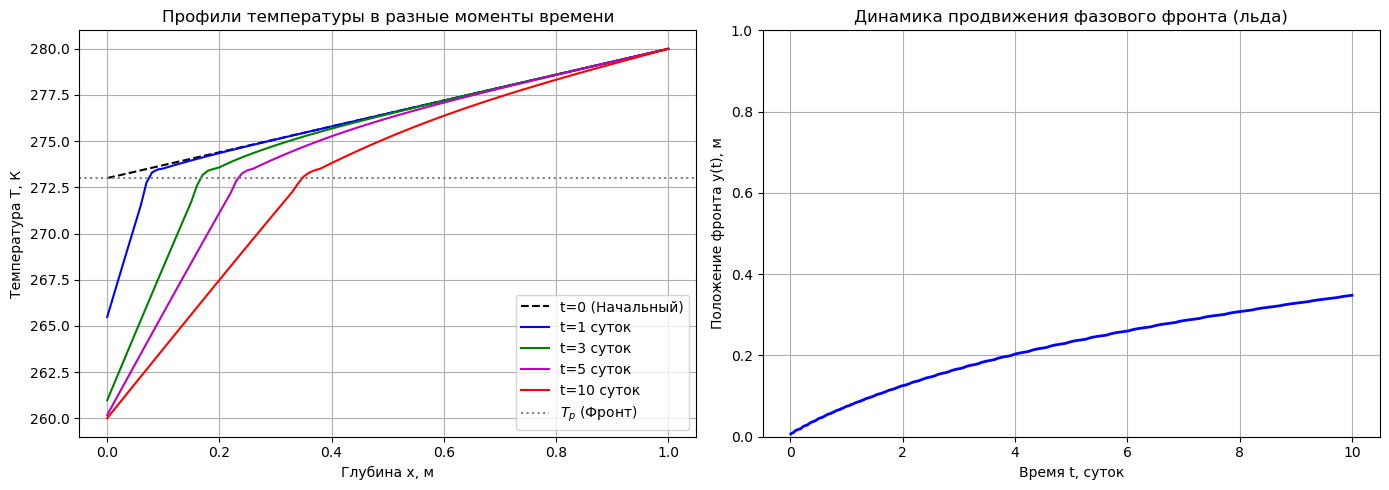

In [50]:
# ==========================================
# 6. ВИЗУАЛИЗАЦИЯ
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График профилей температур T(x)
axes[0].plot(x, g(x), 'k--', label='t=0 (Начальный)')
colors = ['b', 'g', 'm', 'r']
for i, (day, T_prof) in enumerate(sorted(saved_profiles.items())):
    axes[0].plot(x, T_prof, color=colors[i%len(colors)], label=f't={day} суток')
    
axes[0].axhline(Tp, color='grey', linestyle=':', label='$T_p$ (Фронт)')
axes[0].set_xlabel('Глубина x, м')
axes[0].set_ylabel('Температура T, К')
axes[0].set_title('Профили температуры в разные моменты времени')
axes[0].legend()
axes[0].grid(True)

# График положения фронта y(t)
axes[1].plot(front_time, front_pos, 'b-', linewidth=2)
axes[1].set_xlabel('Время t, суток')
axes[1].set_ylabel('Положение фронта y(t), м')
axes[1].set_title('Динамика продвижения фазового фронта (льда)')
axes[1].grid(True)
axes[1].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()